# Project 3B — Multi-tone Signal Analyser

## What this project does
Generates a signal made of multiple frequency components, analyses it
with FFT, then uses a bandpass filter to isolate one specific tone.

## Key concept
Real RF signals are mixtures of frequencies. Filters let you isolate
exactly the band you want — this is the foundation of every radio receiver.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sp

In [24]:
fs = 5000
t = np.arange(0, 1, 1/fs)

f1, a1 = 100, 1
f2, a2 = 500, 0.6
f3, a3 = 1200, 0.3

tone1 = a1 * np.sin(2*np.pi*f1*t)
tone2 = a2 * np.sin(2*np.pi*f2*t)
tone3 = a3 * np.sin(2*np.pi*f3*t)

mixed = tone1+tone2+tone3

print(f"Tones: {f1} Hz (A={a1}), {f2} Hz (A={a2}), {f3} Hz (A={a3})")
print(f"Sampling rate: {fs} Hz")

Tones: 100 Hz (A=1), 500 Hz (A=0.6), 1200 Hz (A=0.3)
Sampling rate: 5000 Hz


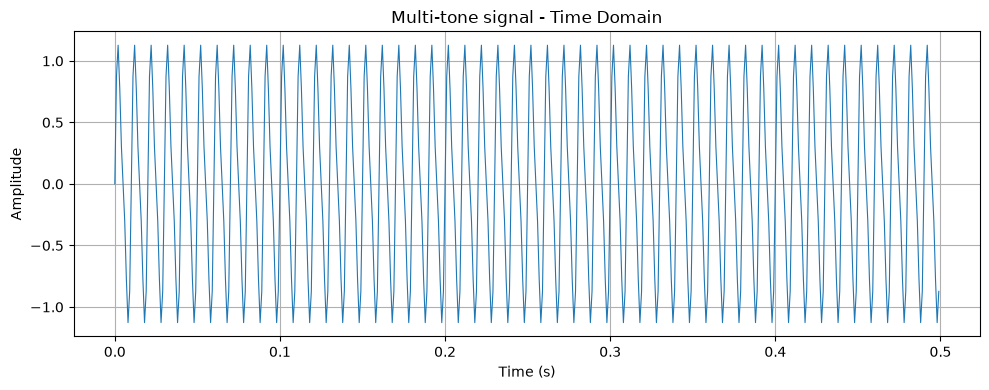

In [18]:
plt.figure(figsize = (10,4))
plt.plot(t[:500], mixed[:500], linewidth=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Multi-tone signal - Time Domain")
plt.grid(True)
plt.tight_layout()
plt.show()

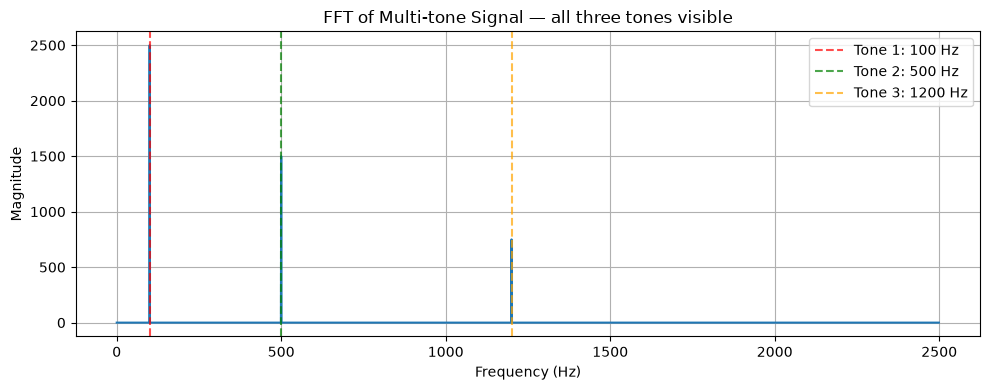

In [25]:
N = len(mixed)
half = N//2
fft = np.abs(np.fft.fft(mixed))[:half]
freq = np.fft.fftfreq(len(mixed), 1/fs)[:half]

plt.figure(figsize=(10,4))
plt.plot(freq, fft)
plt.axvline(x=f1, color='r', linestyle='--', alpha=0.7, label=f"Tone 1: {f1} Hz")
plt.axvline(x=f2, color='g', linestyle='--', alpha=0.7, label=f"Tone 2: {f2} Hz")
plt.axvline(x=f3, color='orange', linestyle='--', alpha=0.7, label=f"Tone 3: {f3} Hz")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT of Multi-tone Signal — all three tones visible")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
low = 400
high = 600

sos = sp.butter(10, [low, high], btype="bandpass", fs = fs, output = 'sos')
# sp.butter(): designs a Butterworth filter
# 10: filter order — higher order = sharper cutoff edges
# [low, high]: list of cutoff frequencies defining the passband
# btype='bandpass': keeps frequencies BETWEEN low and high, removes everything else
# fs=fs: sampling rate so frequencies are interpreted correctly
# output='sos': second-order sections format — more numerically stable than default

filtered = sp.sosfilt(sos, mixed)

print(f"Bandpass filter: {low}–{high} Hz")
print(f"This should isolate tone 2 at {f2} Hz")

Bandpass filter: 400–600 Hz
This should isolate tone 2 at 500 Hz


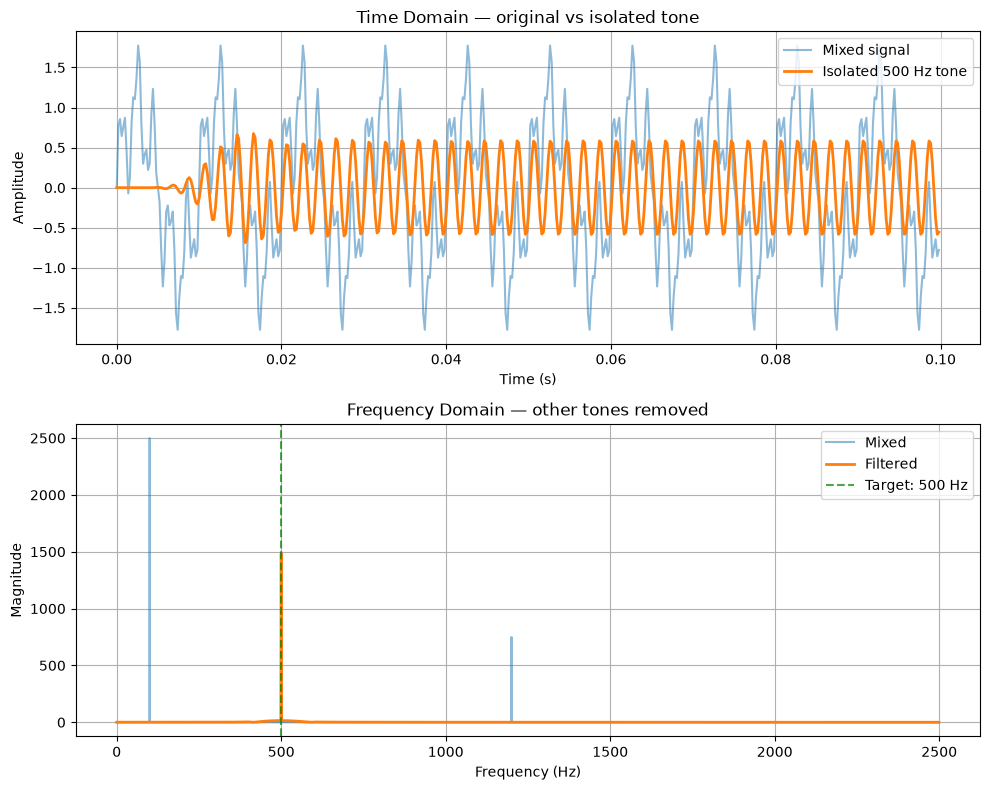

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))


axes[0].plot(t[:500], mixed[:500], label = "Mixed signal", alpha=0.5)
axes[0].plot(t[:500], filtered[:500], label=f"Isolated {f2} Hz tone", linewidth=2)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Time Domain — original vs isolated tone")
axes[0].legend()
axes[0].grid(True)

fft_filt = np.abs(np.fft.fft(filtered))[:half]
axes[1].plot(freq, fft, label="Mixed", alpha=0.5)
axes[1].plot(freq, fft_filt, label="Filtered",linewidth=2)

axes[1].axvline(x=f2, color='g', linestyle='--', alpha=0.7, label=f"Target: {f2} Hz")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Magnitude")
axes[1].set_title("Frequency Domain — other tones removed")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()



## Key observations
- Mixed signal in time domian looks like a noise but the single tone signal is a sine wave signal 
- Spikes appear in FFT at frequencies equal to 100, 500 and 1200 Hz and the spike hright showing the relative power of each component simultaneously.
- Bandpass filter has cleanly isolated the frequency at 500 Hz

## What I learned
- Real signals are mixtures of many frequencies added together
- FFT reveals all the individual frequency components hidden in a complex signal
- A bandpass filter selectively extracts one frequency band — this is how radio receivers work
- Butterworth filter gives a smooth rolloff compared to the sharp FIR filter from Project 1